# Project Structure for Jupyter **Notebook** **bold text**

In [ ]:
#1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

#2. Dataset

In [3]:
df = pd.read_csv('/Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

#3. Data Cleaning


*   Check Missing Values
*   Check Data Types
*   Convert TotalCharges to Numeric
*   Check Missing Values Again
*   Remove Missing Rows

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df = df.dropna()

In [11]:
df.shape

(7032, 21)

#4. Customer Retention & Churn KPI Analysis


*   Total Customers
*   Total Churned Customers
*   Churn Rate

In [12]:
total_customers = df['customerID'].nunique()

print(total_customers)

7032


In [13]:
churned_customers = (
    df[df['Churn'] == 'Yes']
    ['customerID']
    .nunique()
)

print(churned_customers)

1869


In [15]:
churn_rate = (
    churned_customers /
    total_customers
) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


# **Business Insight**

Churn Rate measures the percentage of customers who left the company.

# 5. Contract Type Analysis

*   Churn by Contract

In [16]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


Visualization:Expected Finding

Month-to-month customers typically have the highest churn.

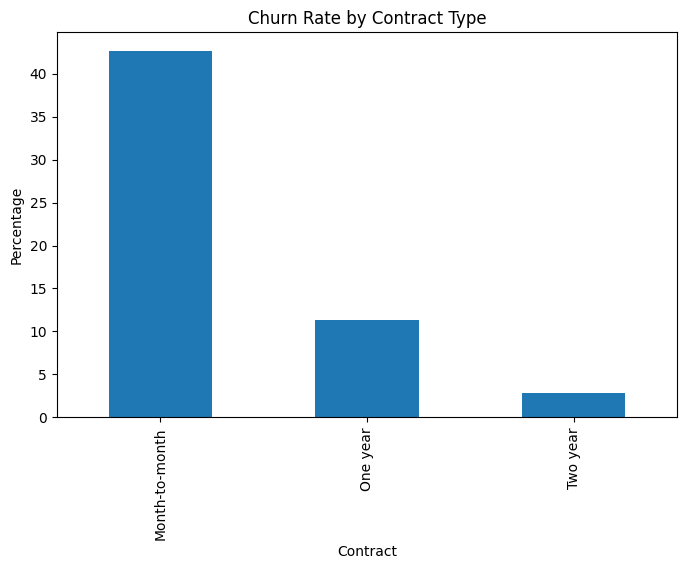

In [17]:
contract_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Churn Rate by Contract Type')
plt.ylabel('Percentage')
plt.show()

# 6.Internet Service Analysis

In [18]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


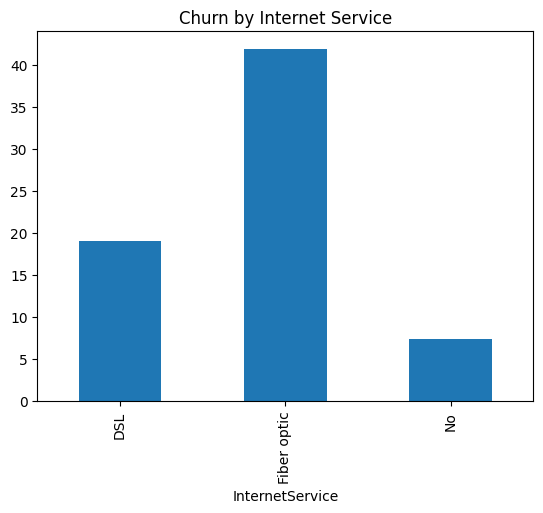

In [19]:
internet_churn['Yes'].plot(
    kind='bar'
)

plt.title('Churn by Internet Service')
plt.show()

# 7. Payment Method Analysis


In [20]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


# 8. Customer Lifetime Analysis
Tenure represents customer lifetime.


*   Compare Tenure by Churn

average Tenure

In [21]:
df['tenure'].mean()

np.float64(32.421786120591584)

In [22]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


Visualization:Customers with shorter tenure are more likely to churn.

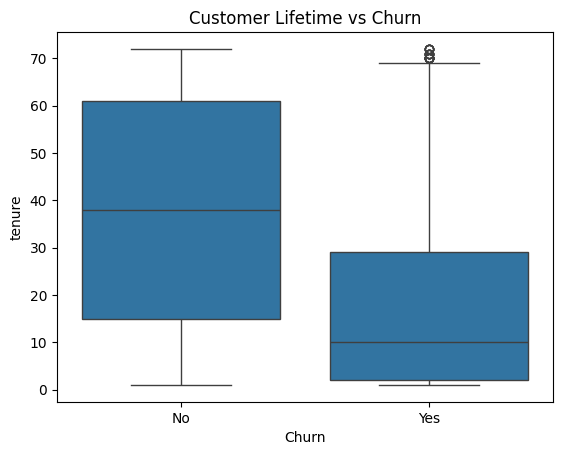

In [23]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Customer Lifetime vs Churn')
plt.show()

# 9.Revenue Impact of Churn


*   Monthly Revenue
*   Revenue Lost
This estimates recurring monthly revenue lost due to churn.bold text



In [24]:
df['MonthlyCharges'].sum()

np.float64(455661.0)

In [25]:
lost_revenue = df[
    df['Churn'] == 'Yes'
]['MonthlyCharges'].sum()

lost_revenue

np.float64(139130.85)

# **10. Customer Segmentation**


*   Senior Citizens
*   Partner Status
*   Dependents

In [26]:
pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [27]:
pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


In [29]:
pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


# **Executive Summary**
**Key Findings**
Overall churn rate is 26.58%.
Month-to-month contracts show the highest churn.
Customers with shorter tenure churn more frequently.
Electronic check users have higher churn rates.
Fiber optic customers show elevated churn levels.
Churn results in significant monthly revenue loss.
**Recommendations**
Promote annual contracts.
Create loyalty programs for new customers.
Offer discounts before contract expiration.
Improve retention strategies for high-risk customer groups.
Contact customers showing churn indicators early.